<a href="https://colab.research.google.com/github/remyaP12/WebProject/blob/main/flood%20prediction%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1258/1258 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 4.1446e-04
Epoch 2/20
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 1.6406e-04
Epoch 3/20
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 1.5590e-04
Epoch 4/20
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 1.3973e-04
Epoch 5/20
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 1.3465e-04
Epoch 6/20
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 1.2585e-04
Epoch 7/20
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 1.2437e-04
Epoch 8/20
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 1.1832e-04
Epoch 9/20
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 1.1899e-04
Epoch 10/20
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 1.1559e-04
Epoch 11/20
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 1.1875e-04
Epoch 12/20
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 1.1421e-04
Epoch 13/20
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 1.1355e-04
Epoch 14/20
1258/1258 ━━━━━━━━━━

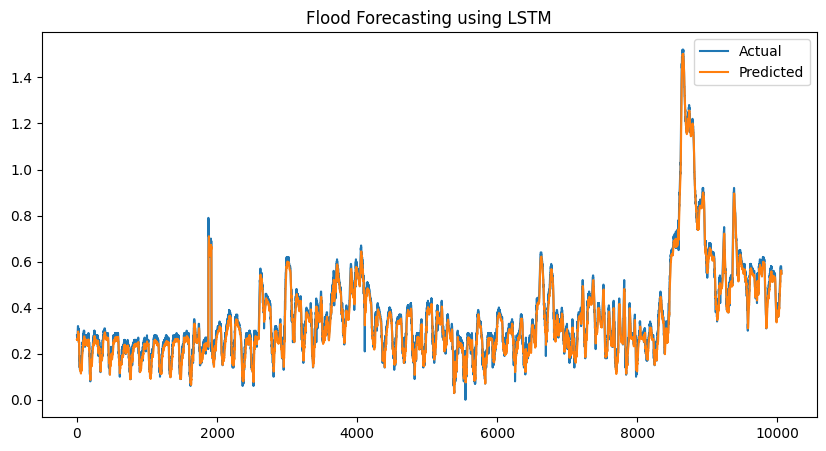


Sample Predictions:

Actual: 0.28 | Predicted: 0.26 | Flood: 0
Actual: 0.28 | Predicted: 0.26 | Flood: 0
Actual: 0.28 | Predicted: 0.26 | Flood: 0
Actual: 0.28 | Predicted: 0.26 | Flood: 0
Actual: 0.28 | Predicted: 0.26 | Flood: 0
Actual: 0.27 | Predicted: 0.26 | Flood: 0
Actual: 0.28 | Predicted: 0.26 | Flood: 0
Actual: 0.28 | Predicted: 0.26 | Flood: 0
Actual: 0.27 | Predicted: 0.26 | Flood: 0
Actual: 0.28 | Predicted: 0.26 | Flood: 0


In [3]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv('flood_train.csv')

# Change column name if needed
data = df[['waterlevel']].values

# =========================
# 3. NORMALIZATION
# =========================
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

# =========================
# 4. CREATE TIME SERIES
# =========================
def create_dataset(dataset, time_step=10):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 10
X, y = create_dataset(data_scaled, time_step)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# =========================
# 5. TRAIN TEST SPLIT
# =========================
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# =========================
# 6. LSTM MODEL
# =========================
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

# =========================
# 7. PREDICTION
# =========================
pred = model.predict(X_test)

# Inverse scaling
pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# =========================
# 8. FLOOD THRESHOLD
# =========================
flood_threshold = np.percentile(y_test_actual, 90)

flood_pred = (pred > flood_threshold).astype(int)

# =========================
# 9. EVALUATION
# =========================
print("\nLSTM Performance:")
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, pred)))
print("MAE :", mean_absolute_error(y_test_actual, pred))
print("R2  :", r2_score(y_test_actual, pred))

# =========================
# 10. VISUALIZATION
# =========================
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("Flood Forecasting using LSTM")
plt.show()

# =========================
# 11. OUTPUT DISPLAY
# =========================
print("\nSample Predictions:\n")

for i in range(10):
    print(f"Actual: {y_test_actual[i][0]:.2f} | Predicted: {pred[i][0]:.2f} | Flood: {flood_pred[i][0]}")